In [2]:
import pandas as pd

# Load the data
df = pd.read_csv("all_data.csv")  # use your path
df.head()


,attention,meditation,delta,theta,lowAlpha,highAlpha,lowBeta,highBeta,lowGamma,highGamma,blinkStrength,time
0,54,43,1628511,1226061,49519,76203,67097,42985,36232,66400,0,0.173095
1,54,43,1628511,1226061,49519,76203,67097,42985,36232,66400,50,0.352463
2,47,38,1364118,74112,21034,26251,63036,15680,14293,23903,0,1.169206
3,63,50,55846,32601,15877,11912,11351,16628,20074,5642,0,2.158505
4,61,34,503036,32190,2574,4902,1359,6324,2695,3091,0,3.174575


In [3]:
def eeg_label(value):
    if value < 34:
        return "Low"
    elif value < 67:
        return "Medium"
    else:
        return "High"


In [4]:
# Create new labeled columns
df["attention_label"] = df["attention"].apply(eeg_label)
df["relaxation_label"] = df["meditation"].apply(eeg_label)

# Preview results
print(df[["attention", "attention_label", "meditation", "relaxation_label"]].head(10))


   attention attention_label  meditation relaxation_label
0         54          Medium          43           Medium
1         54          Medium          43           Medium
2         47          Medium          38           Medium
3         63          Medium          50           Medium
4         61          Medium          34           Medium
5         81            High          47           Medium
6         93            High          53           Medium
7        100            High          48           Medium
8        100            High          48           Medium
9        100            High          48           Medium


In [5]:
print("Attention label counts:\n", df["attention_label"].value_counts())
print("Relaxation label counts:\n", df["relaxation_label"].value_counts())


Attention label counts:
 attention_label
Medium    3144
High      1567
Low       1218
Name: count, dtype: int64
Relaxation label counts:
 relaxation_label
Medium    3803
High      1264
Low        862
Name: count, dtype: int64


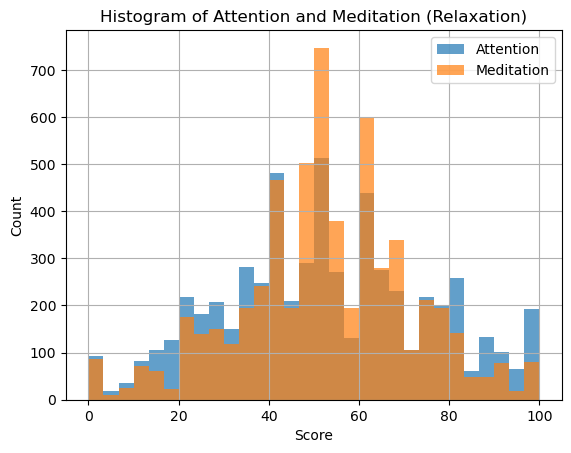

In [6]:
import matplotlib.pyplot as plt

# Plot histograms
df["attention"].hist(bins=30, alpha=0.7, label="Attention")
df["meditation"].hist(bins=30, alpha=0.7, label="Meditation")
plt.legend()
plt.title("Histogram of Attention and Meditation (Relaxation)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()


In [7]:
# 5. Save Labeled Data
df.to_csv("all_data_labeled_att_Rel.csv", index=False)